In [1]:
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline
import numpy as np
from UTILS import Verlet_Update, InitialCondition
from scipy.stats import maxwell

# Costants

In [2]:
class constants:
    mass = 1.6735575e-27 # kg, mass Hbar
    bohr_magneton = 9.2740100657e-24 # J/T, CODATA 2022
    kB = 1.380649e-23   # J/K
    Temperature = 10e-3 # K
    Zmin = -605 # mm
    Zmax = -481 # mm
    Zmid = -544 # mm

CONSTANTS = constants()

# Functions to make the plot nicer

In [3]:
# Make Plot Nicer
def plotter_nicer(titlex, titley):
    plt.ylabel(titley, fontsize = 18, loc = "top")
    plt.xlabel(titlex, loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia

def labelfactory(x, y , listlist, labels):
    plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

    texts = []
    for xi, yi, label in zip(x, y, listlist):
        texts.append(plt.text(xi - 0.2, yi, label, rotation = 30))
    
    adjust_text(texts, x, y, arrowprops=dict(arrowstyle="->", color='white'))
    
    plt.legend(fontsize = 12)

# Boltzmann-Maxwell distribution

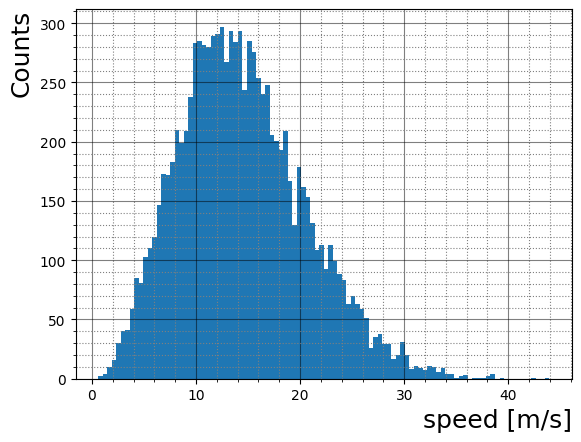

In [4]:
scale = np.sqrt(CONSTANTS.kB * CONSTANTS.Temperature/CONSTANTS.mass)
sampling = maxwell.rvs(scale = scale, size = 10000)
plt.hist(sampling, bins = 100)
plotter_nicer("speed [m/s]", "Counts")

In [5]:
data = np.genfromtxt("Bfield/GravityRelease_17mT_well_0g.csv", 
                       delimiter = ",", 
                       names = True, 
                       filling_values=np.nan, 
                       #unpack =  True
                      )

print(type(data))
print(10*"-")
print(data)
print(10*"-")
print(data[0])
print(10*"-")
print(data[0][0], data[0][1] )
print(10*"-")
print(data["z_mm__Min_B_on_wall"])
#Z, Potential, Z_minwall, PotentialMinWall 

<class 'numpy.ndarray'>
----------
[(-3000., -0.00466541, -1000. , 0.779142)
 (-2997., -0.0046565 ,  -999.5, 0.780243)
 (-2994., -0.00464758,  -999. , 0.781342) ...
 ( 2994.,  0.00595181,     nan,      nan)
 ( 2997.,  0.00595341,     nan,      nan)
 ( 3000.,  0.00595504,     nan,      nan)]
----------
(-3000., -0.00466541, -1000., 0.779142)
----------
-3000.0 -0.00466541
----------
[-1000.   -999.5  -999.  ...     nan     nan     nan]


## Plot of the Magnetic field profile, 17mT well

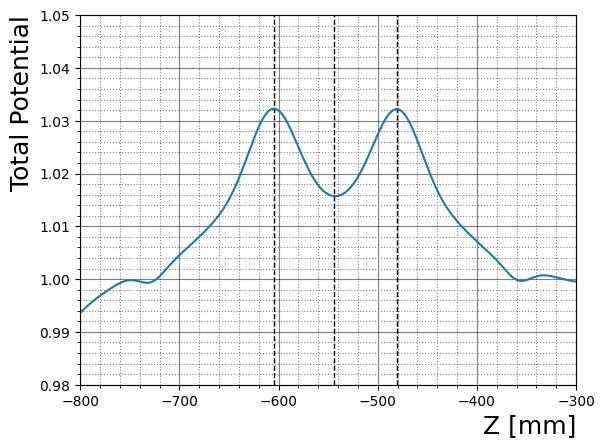

In [6]:
plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-800, -300)
plt.ylim(0.98, 1.05)
plt.axvline(-605, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-544, linestyle = "--", color = "black", linewidth = 1)
plt.axvline(-481, linestyle = "--", color = "black", linewidth = 1)
plt.plot(data['\ufeffz_mm__Bz_on_axis'],data["Total_potential_T__Bz_on_axis"] )

## Spline Creation

- **Bfield(x)** Magnetic Field Potential

In [7]:
Z = data['\ufeffz_mm__Bz_on_axis']
print(Z)
Uz = data["Total_potential_T__Bz_on_axis"]
Bfield = CubicSpline(Z, Uz)

[-3000. -2997. -2994. ...  2994.  2997.  3000.]


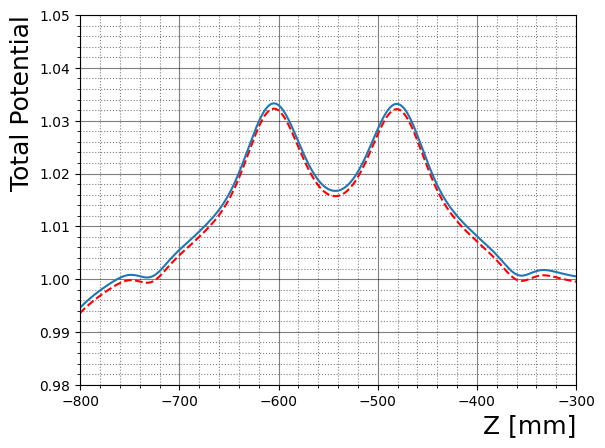

In [8]:
plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-800, -300)
plt.ylim(0.98, 1.05)

plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.plot(Z,data["Total_potential_T__Bz_on_axis"] + 0.001 )

# Energy Distribution

In [9]:
from scipy.optimize import brentq

<ErrorbarContainer object of 3 artists>

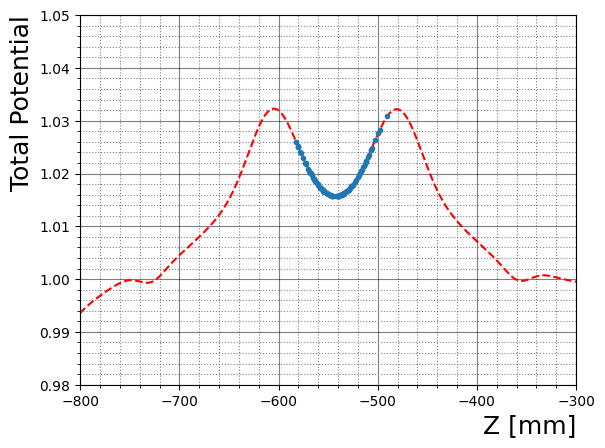

In [10]:
nAtoms = 100

Zinit = [InitialCondition(Bfield, CONSTANTS)[1] for i in range(0,nAtoms)]

plotter_nicer("Z [mm]", "Total Potential")
plt.xlim(-800, -300)
plt.ylim(0.98, 1.05)
plt.plot(Z, Bfield(Z), linestyle = "--", color = "red")
plt.errorbar(Zinit, Bfield(Zinit), linestyle = "", marker = ".")